In [49]:
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
import warnings
warnings.filterwarnings('ignore')

In [50]:
df = pd.read_csv("../Data/data_preprocessed.csv")
df.head()

,Exercise_Frequency,Blood_Pressure,Stress_Level,Age,BMI,Heart_Rate,Sleep_Hours,Blood_Sugar_Level,Family_History,Illness,...,gender_Female,gender_Male,smoking_No,smoking_Yes,Medication_Use_Occasional,Medication_Use_Regular,Alcohol_Consumption_Heavy,Alcohol_Consumption_Moderate,Cholesterol_Level_High,Cholesterol_Level_Normal
0,1,2,3,90,16.6,119,3.6,143.6,0,1,...,1,0,1,0,0,0,0,1,0,0
1,1,2,1,20,29.9,69,9.9,121.8,1,0,...,0,0,0,1,0,0,0,0,0,1
2,4,3,1,52,33.5,54,8.5,107.0,1,1,...,0,1,0,1,0,0,1,0,1,0
3,4,2,1,15,20.3,72,9.5,92.1,0,1,...,0,1,0,0,0,0,0,0,1,0
4,3,3,2,60,36.0,58,4.4,113.6,0,1,...,0,1,1,0,0,0,0,1,1,0


In [51]:
x = df.drop(['Illness'], axis=1)
y = df[['Illness']]

In [52]:
"""std = StandardScaler()
for col in x.columns:
    x[col] = std.fit_transform(x[[col]])"""

'std = StandardScaler()\nfor col in x.columns:\n    x[col] = std.fit_transform(x[[col]])'

In [53]:
xtrain, xtest, ytrain, ytest = train_test_split(x, y, test_size=0.2, random_state=42)

Train Score: 0.5675
Test Score: 0.5
accuracy_score: 0.5


<Axes: >

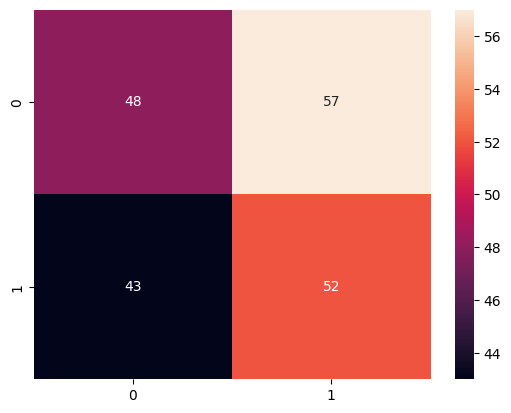

In [54]:
logi = LogisticRegression()
logi_model = logi.fit(xtrain, ytrain)
print(f'Train Score: {logi_model.score(xtrain, ytrain)}')
print(f'Test Score: {logi_model.score(xtest, ytest)}')
logi_pred = logi_model.predict(xtest)
print(f'accuracy_score: {accuracy_score(ytest, logi_pred)}')
cm = confusion_matrix(ytest, logi_pred)
sns.heatmap(cm, annot=True)

Train Score: 0.80875
Test Score: 0.5
accuracy_score: 0.5


<Axes: >

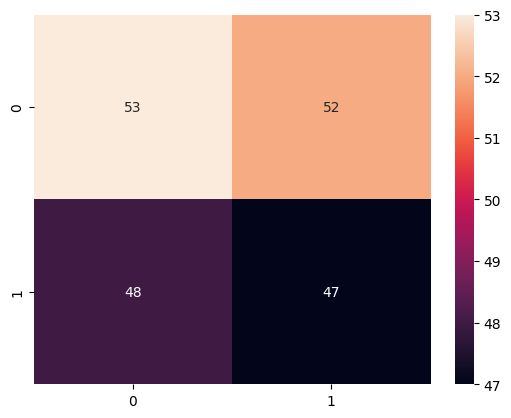

In [55]:
rf_regularized = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,  # depth সীমিত
    min_samples_split=10,  # split করার জন্য minimum samples
    min_samples_leaf=5,  # leaf node এ minimum samples
    max_features='sqrt',  # প্রতি split এ কতগুলো feature
    random_state=42
)
rand_model = rf_regularized.fit(xtrain, ytrain)
print(f'Train Score: {rand_model.score(xtrain, ytrain)}')
print(f'Test Score: {rand_model.score(xtest, ytest)}')
rand_pred = rand_model.predict(xtest)
print(f'accuracy_score: {accuracy_score(ytest, rand_pred)}')
cm = confusion_matrix(ytest, rand_pred)
sns.heatmap(cm, annot=True)